In [1]:
from itertools import chain

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shapely.geometry

mpl.rcParams["figure.dpi"] = 100
import seaborn as sns
sns.set()

import shapely
import networkx as nx

#from src.space.utils import segmented
from src.space.road_network import RoadNetwork
from src.space.utils import _to_gpd
from src.space.road_network import get_from_node
from src.space.road_network import get_to_node
from src.space.road_network import get_path

### 0. Read Data

#### 0.1 Read Population

In [2]:
pop_df = pd.read_csv("data/step1_output/ub_pop.csv").iloc[:,1:]
pop_df= pop_df.rename(columns={"class": "destination", "long": "lat", "lat":"long"})
pop_df.drop("id", axis=1, inplace=True)  # remove id
#pop_df['id']
pop_df.index.name = "id"  # assign id
pop_df.head()

,age,destination,lat,long
id,,,,
0,17,7,43.011568,-78.791918
1,23,2,43.011568,-78.791918
2,24,2,43.011568,-78.791918
3,18,30,43.011568,-78.791918
4,18,2,43.011568,-78.791918


#### 0.2 Walkway

In [3]:
#read road network
ub_walkway = gpd.read_file("../data/walkway_clean.shp")#.drop("Id", axis=1, inplace=True)
ub_walkway.drop("cat_", axis=1, inplace=True) #remove id
ub_walkway.index.name = "unique_id" #assign id

ub_walkway["num_points"] = ub_walkway.apply(
    lambda row: len(row["geometry"].coords), axis=1
)#get the points for each line

print(f"ub_walkway.shape: {ub_walkway.shape}")
#read nodes
ub_walkway.head()

ub_walkway.shape: (519, 4)


,cat,comp,geometry,num_points
unique_id,,,,
0,1,1,"LINESTRING (-78.78682 43.00841, -78.78675 43.0...",2
1,6,2,"LINESTRING (-78.78604 43.00303, -78.78604 43.0...",3
2,7,2,"LINESTRING (-78.79346 43.00136, -78.79372 43.0...",4
3,9,2,"LINESTRING (-78.78843 43.00053, -78.78878 43.0...",3
4,10,2,"LINESTRING (-78.78923 43.00047, -78.78922 43.0...",3


<Axes: >

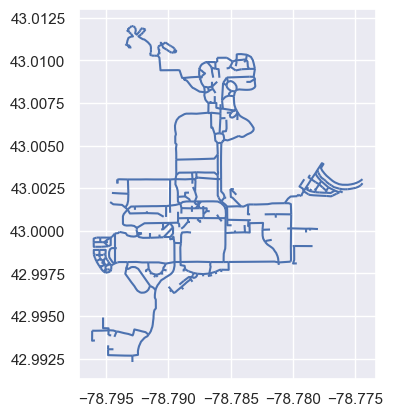

In [4]:
ub_walkway.plot()

#### 0.3 Buildings

In [5]:
# class building
class_bld = gpd.read_file("data/step1_output/class_building_points.shp")
# resident building
res_bld = gpd.read_file("data/step1_output/res_building_points.shp")

### 1, Get Nodes for the UB walkways

total number of road vertices: 1555


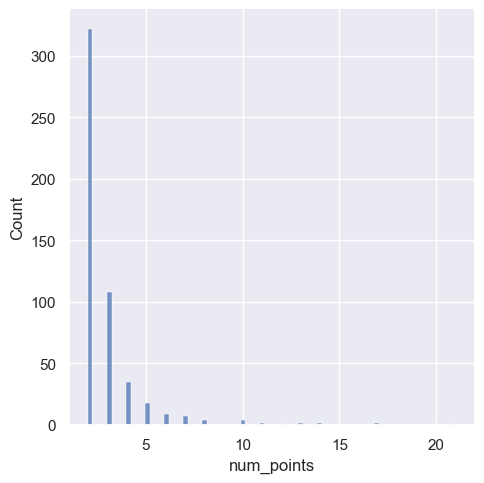

In [6]:
print(f"total number of road vertices: {ub_walkway['num_points'].sum()}")
sns.displot(x="num_points", data=ub_walkway, kind="hist")

In [7]:
points_df = pd.Series(
    list(
        chain.from_iterable(
            ub_walkway.apply(lambda line: [p for p in line["geometry"].coords], axis=1)
        )
    )
).to_frame()

print(f"points_df.shape: {points_df.shape}")
points_df.head()

points_df.shape: (1555, 1)


,0
0,"(-78.78681835316166, 43.00841032684591)"
1,"(-78.78675189319803, 43.00818831274323)"
2,"(-78.78604246378319, 43.003031626950616)"
3,"(-78.78604038974248, 43.002068367244455)"
4,"(-78.78597330414166, 43.00195686339144)"


In [8]:
import shapely.geometry
points_count_df = (
    points_df.value_counts()
    .to_frame()
    .rename(columns={0: "count"})
    .reset_index()
    .rename(columns={0: "coord"})
)

ub_walkway_vertices = gpd.GeoDataFrame(
    points_count_df,
    geometry=points_count_df["coord"].apply(lambda p: shapely.geometry.Point(p)),
)

ub_walkway_vertices.drop("coord", axis=1, inplace=True)
print(f"ub_walkway_vertices.shape: {ub_walkway_vertices.shape}")
ub_walkway_vertices.head()

ub_walkway_vertices.shape: (925, 2)


,count,geometry
0,6,POINT (-78.79523 42.99825)
1,5,POINT (-78.78748 43.00894)
2,5,POINT (-78.78775 43.00311)
3,5,POINT (-78.79516 42.99803)
4,5,POINT (-78.79525 42.99813)


<Axes: >

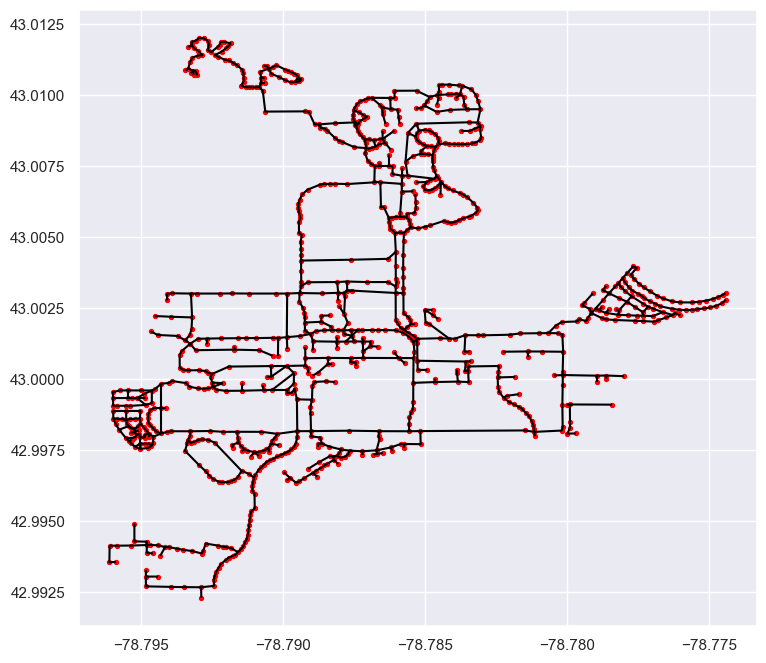

In [9]:
ax = ub_walkway.plot(figsize=(10, 8), color="black")
ub_walkway_vertices.plot(ax=ax, markersize=8, color="red", marker="o")

### 2. Create Network from the Walkway shapefile

In [10]:
ub_walkway_network = RoadNetwork(lines=ub_walkway["geometry"])

ub_walkway_segmented.shape: (1036, 1)
                                            geometry
0  LINESTRING (-78.78682 43.00841, -78.78675 43.0...
1  LINESTRING (-78.78604 43.00303, -78.78604 43.0...
2  LINESTRING (-78.78604 43.00207, -78.78597 43.0...
3  LINESTRING (-78.79346 43.00136, -78.79372 43.0...
4  LINESTRING (-78.79372 43.00152, -78.79443 43.0...


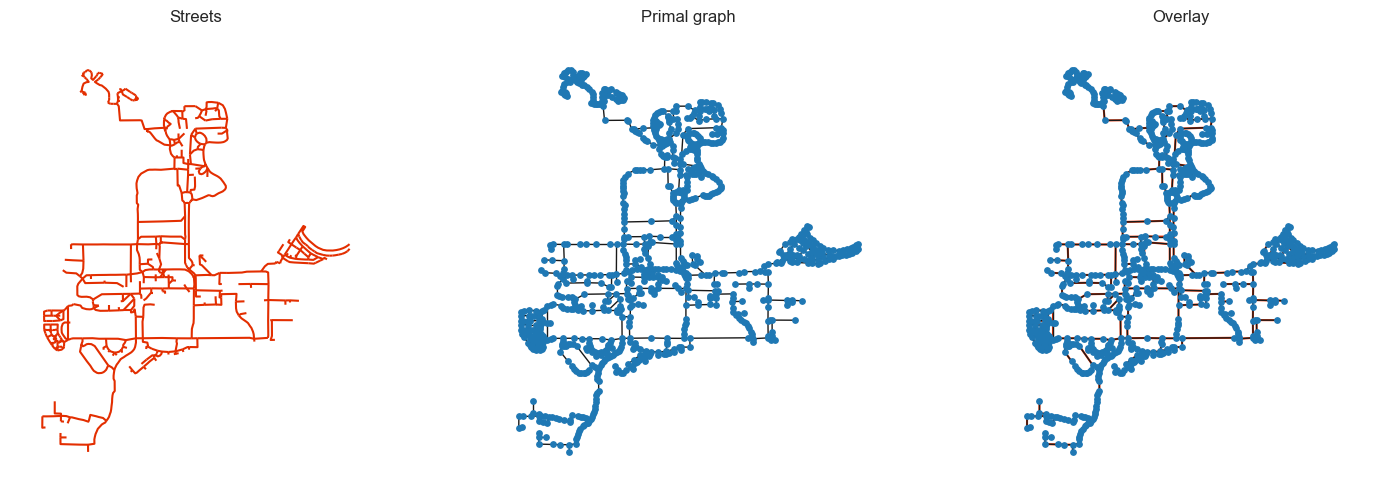

In [11]:
f, ax = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
for i, facet in enumerate(ax):
    facet.set_title(("Streets", "Primal graph", "Overlay")[i])
    facet.axis("off")

ub_walkway.plot(color="#e32e00", ax=ax[0])
nx.draw(
    ub_walkway_network.nx_graph,
    {n: [n[0], n[1]] for n in list(ub_walkway_network.nx_graph.nodes)},
    ax=ax[1],
    node_size=15,
)

ub_walkway.plot(color="#e32e00", ax=ax[2], zorder=-1)
nx.draw(
    ub_walkway_network.nx_graph,

    {n: [n[0], n[1]] for n in list(ub_walkway_network.nx_graph.nodes)},
    ax=ax[2],
    node_size=15,
)

### 3, Find the Nearest Node and the Shortest Commute Path for Population

In [12]:
pop_gpd = _to_gpd(pop_df)
pop_gpd.head()

population size (5737, 5)


,age,destination,lat,long,geometry
id,,,,,
0,17,7,43.011568,-78.791918,POINT (-78.79192 43.01157)
1,23,2,43.011568,-78.791918,POINT (-78.79192 43.01157)
2,24,2,43.011568,-78.791918,POINT (-78.79192 43.01157)
3,18,30,43.011568,-78.791918,POINT (-78.79192 43.01157)
4,18,2,43.011568,-78.791918,POINT (-78.79192 43.01157)


In [13]:
pop_gpd.tail()

,age,destination,lat,long,geometry
id,,,,,
5732,19,3,43.000726,-78.791744,POINT (-78.79174 43.00073)
5733,21,13,43.000726,-78.791744,POINT (-78.79174 43.00073)
5734,18,9,43.000726,-78.791744,POINT (-78.79174 43.00073)
5735,25,18,43.000726,-78.791744,POINT (-78.79174 43.00073)
5736,18,0,43.000726,-78.791744,POINT (-78.79174 43.00073)


<Axes: >

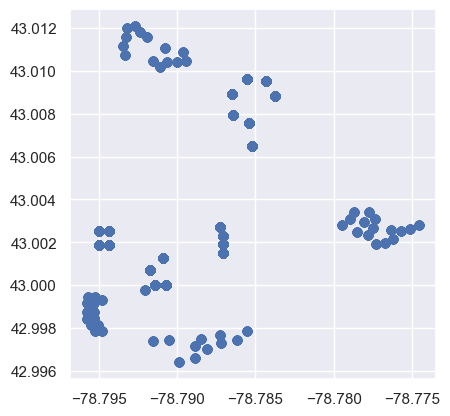

In [14]:
pop_gpd.plot()

### Workflow
* step1 add from_node and to_node for the population dataset
    * function to get node based on geomtery for class building
    * Get the rom_node and to_node based on the class building
* step2 calculate the path based on the from and to nodes

In [15]:
#set the class building starting node
class_bld['n_node'] = class_bld.apply(get_from_node, args=(ub_walkway_network,), axis = 1)
class_bld.head()

,id,geometry,n_node
0,0,POINT (-78.78561 43.00889),"(-78.78561218938887, 43.008671517699845)"
1,1,POINT (-78.78438 43.00904),"(-78.78459909273391, 43.00940971124479)"
2,2,POINT (-78.78285 43.00101),"(-78.78296754408233, 43.00154060163194)"
3,3,POINT (-78.78108 43.00043),"(-78.78137507083858, 43.000768861435624)"
4,4,POINT (-78.77897 42.99977),"(-78.7789495702452, 42.999899024083696)"


In [16]:
pop_gpd

,age,destination,lat,long,geometry
id,,,,,
0,17,7,43.011568,-78.791918,POINT (-78.79192 43.01157)
1,23,2,43.011568,-78.791918,POINT (-78.79192 43.01157)
2,24,2,43.011568,-78.791918,POINT (-78.79192 43.01157)
3,18,30,43.011568,-78.791918,POINT (-78.79192 43.01157)
4,18,2,43.011568,-78.791918,POINT (-78.79192 43.01157)
...,...,...,...,...,...
5732,19,3,43.000726,-78.791744,POINT (-78.79174 43.00073)
5733,21,13,43.000726,-78.791744,POINT (-78.79174 43.00073)
5734,18,9,43.000726,-78.791744,POINT (-78.79174 43.00073)


<Axes: >

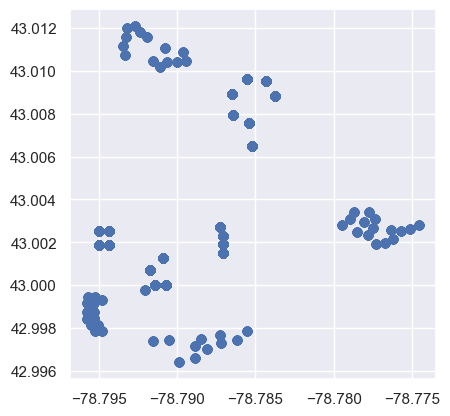

In [19]:
pop_gpd.plot()

In [20]:
#add from_node and to_node for the population dataset
pop_gpd['from_node'] = pop_gpd.apply(get_from_node, args=(ub_walkway_network,), axis = 1)
pop_gpd['to_node'] = pop_gpd.apply(get_to_node, args=(class_bld,ub_walkway_network, ), axis = 1)
pop_gpd.head()

,age,destination,lat,long,geometry,from_node,to_node
id,,,,,,,
0,17,7,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.7860989243901, 43.00094287299057)"
1,23,2,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.78296754408233, 43.00154060163194)"
2,24,2,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.78296754408233, 43.00154060163194)"
3,18,30,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.7854260719746, 43.00785835243767)"
4,18,2,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.78296754408233, 43.00154060163194)"


In [21]:
pop_gpd.from_node.unique()

array([(-78.79203050877528, 43.01164409103028),
       (-78.79108868426844, 43.01027509023015),
       (-78.7899289694516, 43.01052738275656),
       (-78.79065171333608, 43.0104273077254),
       (-78.791399756021, 43.01047235524397),
       (-78.78943730566377, 43.010480972015515),
       (-78.79325156984213, 43.01076865645427),
       (-78.78971867078128, 43.01080584720277),
       (-78.79328847490734, 43.011155089087815),
       (-78.79313831050666, 43.011645804897164),
       (-78.79223464259545, 43.01177183573345),
       (-78.7932200964749, 43.01188311828038),
       (-78.79280312211229, 43.01200244534878),
       (-78.79068887506197, 43.01102657645552),
       (-78.78721501710748, 42.99745720029524),
       (-78.7904924712362, 42.997422250632226), (-78.791463, 42.997455),
       (-78.78615539344375, 42.99745987611258),
       (-78.78721234129016, 42.997326085245945),
       (-78.78838167346453, 42.99762310096987),
       (-78.78988409365968, 42.99643556598094),
       (-78.7857

In [22]:
pop_gpd['commute_path'] = pop_gpd.apply(get_path, args=(ub_walkway_network,), axis=1)
pop_gpd.head()

,age,destination,lat,long,geometry,from_node,to_node,commute_path
id,,,,,,,,
0,17,7,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.7860989243901, 43.00094287299057)","[(-78.79203050877528, 43.01164409103028), (-78..."
1,23,2,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.78296754408233, 43.00154060163194)","[(-78.79203050877528, 43.01164409103028), (-78..."
2,24,2,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.78296754408233, 43.00154060163194)","[(-78.79203050877528, 43.01164409103028), (-78..."
3,18,30,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.7854260719746, 43.00785835243767)","[(-78.79203050877528, 43.01164409103028), (-78..."
4,18,2,43.011568,-78.791918,POINT (-78.79192 43.01157),"(-78.79203050877528, 43.01164409103028)","(-78.78296754408233, 43.00154060163194)","[(-78.79203050877528, 43.01164409103028), (-78..."


In [23]:
pop_gpd.to_csv("../data/population/ub_pop_with_path.csv")